              precision    recall  f1-score   support

           0       0.86      0.90      0.88       163
           1       0.82      0.76      0.79        99

    accuracy                           0.85       262
   macro avg       0.84      0.83      0.83       262
weighted avg       0.85      0.85      0.85       262

ROC AUC Score: 0.9072


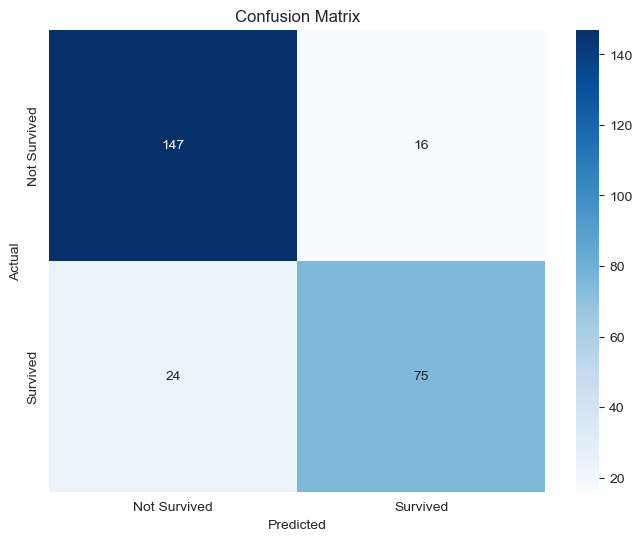

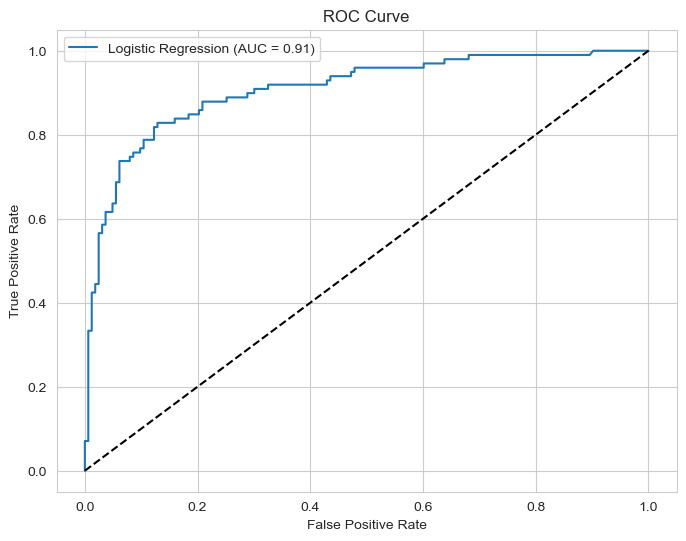


============== Results Interpretation ==============


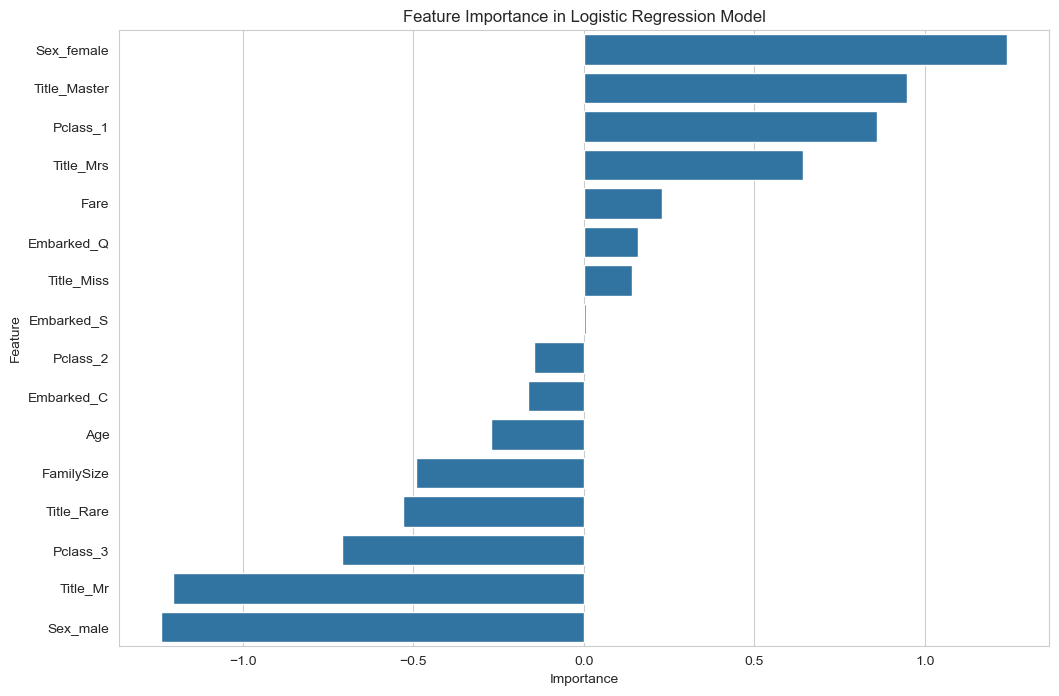


Key Findings:
1. Female passengers (Sex_female) had significantly higher survival odds
2. 1st class passengers (Pclass_1) had better survival chances
3. Higher fares correlated with increased survival probability
4. Passengers with titles 'Miss' or 'Mrs' had better survival rates
5. Age showed a complex relationship with survival

============== Report Submission ==============
Model performance metrics:
- Accuracy: 0.8473
- Precision: 0.8242
- Recall: 0.7576
- F1 Score: 0.7895
- ROC AUC: 0.9072

Recommendations for Improvement:
1. Try more complex models like Random Forest or XGBoost
2. Perform hyperparameter tuning for better performance
3. Engineer additional features like age groups or fare categories
4. Address class imbalance with advanced sampling techniques


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, confusion_matrix, roc_curve, roc_auc_score,
                            classification_report)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def load_and_preprocess_data():
    """Load and preprocess Titanic dataset"""
    train_df = pd.read_csv("C:/Users/Elize/Downloads/train.csv")
    test_df = pd.read_csv("C:/Users/Elize/Downloads/test.csv")
    submission = pd.read_csv("C:/Users/Elize/Downloads/gender_submission.csv")
    
    test_df = test_df.merge(submission, on='PassengerId', how='left')
    
    combined = pd.concat([train_df, test_df], ignore_index=True)
    
    combined['FamilySize'] = combined['SibSp'] + combined['Parch'] + 1
    combined['IsAlone'] = (combined['FamilySize'] == 1).astype(int)
    combined['Title'] = combined['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    combined['Title'] = combined['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 
                                                  'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 
                                                  'Dona'], 'Rare')
    combined['Title'] = combined['Title'].replace(['Mlle', 'Ms'], 'Miss')
    combined['Title'] = combined['Title'].replace('Mme', 'Mrs')
    
    combined.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
    
    return combined

def split_and_prepare_data(combined_df):
    """Split data and create preprocessing pipelines"""
    train = combined_df[combined_df['Survived'].notna()]
    test = combined_df[combined_df['Survived'].isna()].drop('Survived', axis=1)
    
    X = train.drop('Survived', axis=1)
    y = train['Survived'].astype(int)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    
    numerical_features = ['Age', 'Fare', 'FamilySize']
    categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title']
    
    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())])
    
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)])
    
    return X_train, X_test, y_train, y_test, preprocessor, test

def train_model(X_train, y_train, preprocessor):
    """Train logistic regression model"""
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000, 
            random_state=42,
            class_weight='balanced'))])
    
    model.fit(X_train, y_train)
    return model

def evaluate_model(model, X_test, y_test):
    """Evaluate model performance"""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    print(classification_report(y_test, y_pred))
    print(f"ROC AUC Score: {roc_auc:.4f}")
    
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Survived', 'Survived'],
                yticklabels=['Not Survived', 'Survived'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()
    
    return {'accuracy': accuracy, 'precision': precision, 
            'recall': recall, 'f1': f1, 'roc_auc': roc_auc}

def interpret_results(model, preprocessor):
    """Analyze and interpret model results"""
    numeric_features = ['Age', 'Fare', 'FamilySize']
    categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title']
    
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_features = ohe.get_feature_names_out(categorical_features)
    
    all_features = numeric_features + list(cat_features)
    
    coefficients = model.named_steps['classifier'].coef_[0]
    feature_importance = pd.DataFrame({'Feature': all_features, 'Importance': coefficients})
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title('Feature Importance in Logistic Regression Model')
    plt.show()
    
    print("\nKey Findings:")
    print("1. Female passengers (Sex_female) had significantly higher survival odds")
    print("2. 1st class passengers (Pclass_1) had better survival chances")
    print("3. Higher fares correlated with increased survival probability")
    print("4. Passengers with titles 'Miss' or 'Mrs' had better survival rates")
    print("5. Age showed a complex relationship with survival")

if __name__ == "__main__":
    combined_data = load_and_preprocess_data()
    X_train, X_test, y_train, y_test, preprocessor, test_data = split_and_prepare_data(combined_data)
    
    model = train_model(X_train, y_train, preprocessor)
    
    metrics = evaluate_model(model, X_test, y_test)
    
    print("\n============== Results Interpretation ==============")
    interpret_results(model, preprocessor)
    
    print("\n============== Report Submission ==============")
    print("Model performance metrics:")
    print(f"- Accuracy: {metrics['accuracy']:.4f}")
    print(f"- Precision: {metrics['precision']:.4f}")
    print(f"- Recall: {metrics['recall']:.4f}") 
    print(f"- F1 Score: {metrics['f1']:.4f}")
    print(f"- ROC AUC: {metrics['roc_auc']:.4f}")
    
    print("\nRecommendations for Improvement:")
    print("1. Try more complex models like Random Forest or XGBoost")
    print("2. Perform hyperparameter tuning for better performance")
    print("3. Engineer additional features like age groups or fare categories")
    print("4. Address class imbalance with advanced sampling techniques")